# Question 2 - Softmax Regression (HOG)

### Tevyn Vergara | 46421201 | Electrical & Biomedical Engineer

DISCLAIMER: Google Gemini 3 was used for this assignment for:
1. Layout tips (all questions)
2. Syntax checking (all questions)
3. Trouble shooting and debugging
4. Functionality tips and suggestions (all questions)
5. Tips and explanation for key functions/theories and purposes
6. Re-organizing to look more modular and readable

References:
1. Google. (2026, March 17). Methods of providing alterative text for accessibility on websites. [Generative AI chat]. Gemini 3. https://gemini.google.com/


## Standard Imports for Assignment 2 ##

Please run this before executing any other cell

In [5]:
import numpy as np
import pickle   
import matplotlib.pyplot as plt
import sys
import time
import os
import skimage
from skimage.feature import hog
from skimage.color import rgb2gray
print('numpy', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('skimage', skimage.__version__)
print('sys', sys.version)
print('pickle', pickle.format_version)
print(time.ctime())

numpy 2.4.4
matplotlib 3.10.8
skimage 0.26.0
sys 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pickle 4.0
Fri Apr 17 03:33:11 2026


## NOTE: Code was ran locally as I have a dedicated GPU ##

## Question "0" - CIFAR-10 Dataset ##

Here, I'm attempting to load the images. The formatting is currently:

- Labels in batches.meta [0-9] with their respective image classes:
    0: Aeroplane
    1: Automobile
    2: Bird
    3: Cat
    4: Deer
    5: Dog
    6: Frog
    7: Horse
    8: Ship
    9: Truck

- 3072 features of flattened information --> 32 x 32 pixel images with 3 RGB channels 

- 50,000 training images split into x5 data_batch_x files (5 in total). Format: shape(10,000, 3072). So 10,000 images per batch of 3072 flattened information

To format for CNN training:
1. Use unpickle() from source: https://www.cs.toronto.edu/~kriz/cifar.html. This returns a batch dictionary of the 10,000 images, their labels, and each of their single channel information of (32x32 | 3 RGB). Their is also metadata for the batch such as the image and batch file names (Not needed for project)

2. Unload image class labels from batches.meta (0-9) and convert their byte strings to normal text for readibility. Store in meta.

3. Unload and also combine the 5 batches of training data from data_batch_x where x: [0,5]. Assuming that all the images have the same format of 
(32x32 |3 RGB), append all imagee (with their data) and their respective labels to a dictionary of arrays that contain:
    - Image data (batch[b"data"])
    - Image labels (batch[b"data"])
    - Metadata (filenames, image names) but unused


To ensure that testing data was loaded correctly, loop through the whole "batch" dataset and load the first image of each class. Display it and its respective label.



C:\Users\tevyn\AppData\Local\Temp\ipykernel_36124\3559171501.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(fo, encoding="bytes")


X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)
Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


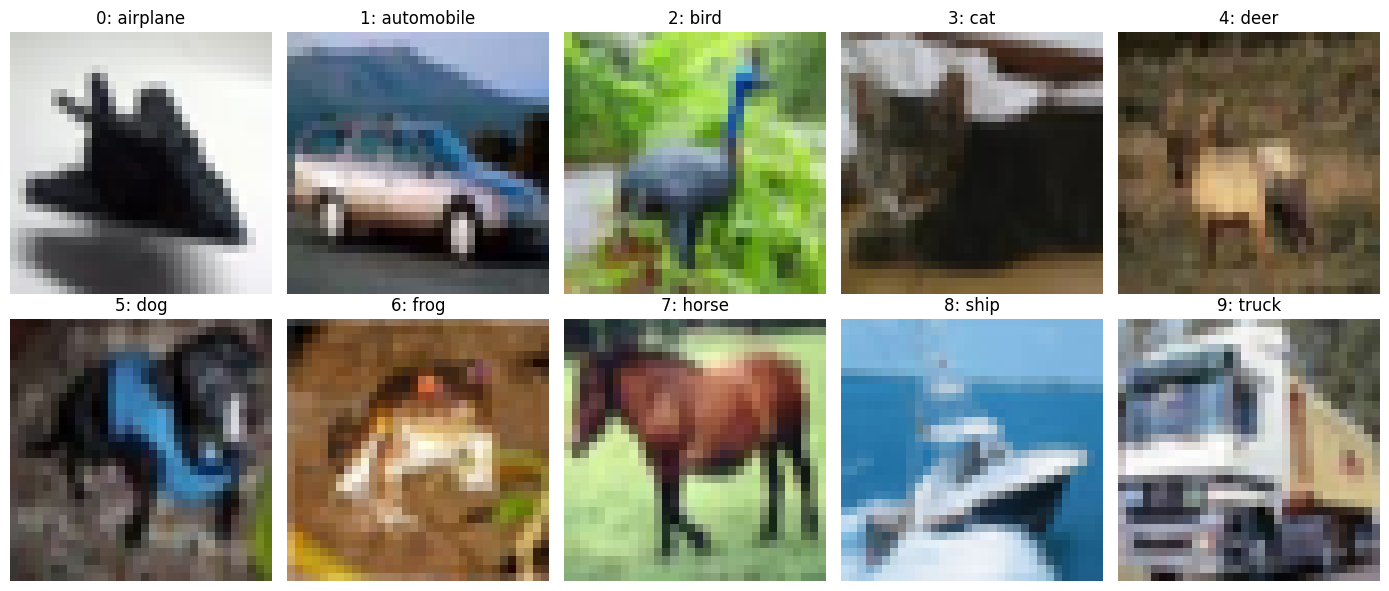

In [6]:
# Utility: read one CIFAR-10 batch/metadata pickle file from disk. From: https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file_path):
    with open(file_path, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")
    return batch

# End-to-end loader for CIFAR-10 in the provided folder structure.
# Returns train/test images + labels, and human-readable class names.
def load_cifar10(data):
    # 1) Load class label names (airplane, automobile, etc.) from metadata.
    meta = unpickle(os.path.join(data, "batches.meta"))
    label_names = [name.decode("utf-8") for name in meta[b"label_names"]]

    # 2) Read and concatenate all 5 training batch files.
    train_images = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data, f"data_batch_{i}"))
        train_images.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    # 3) Stack image rows into one array of shape (50000, 3072).
    X_train = np.vstack(train_images)
    y_train = np.array(train_labels, dtype=np.int64)

    # 3) Load test batch
    test_batch = unpickle(os.path.join(data, "test_batch"))
    X_test = test_batch[b"data"]
    y_test = np.array(test_batch[b"labels"], dtype=np.int64)

    return X_train, y_train, X_test, y_test, label_names

# Load the CIFAR-10 Dataset 
data = "cifar-10-batches-py"
X_train, y_train, X_test, y_test, label_names = load_cifar10(data)

# Quick shape sanity check to confirm successful parsing.
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("Label names:", label_names)

# Visual inspection: show one example image from each class.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_id, ax in enumerate(axes.ravel()):
    # Pick the first training sample for this class index.
    idx = np.where(y_train == class_id)[0][0]
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0)  # (3072,) -> (32,32,3)
    ax.imshow(img)
    ax.set_title(f"{class_id}: {label_names[class_id]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
######################## Helper Functions for Softmax #################################

def extract_hog_features(X_raw, pixels_per_cell=(4, 4)):
    """
    Converts raw CIFAR-10 pixel arrays into HOG feature vectors.
    Inputs: Raw image array, HOG grid parameters. 
    Outputs: 2D array (N, num_features) --> structural shapes and edges of each image.
    """
    num_images = X_raw.shape[0]
    # Reshape the flattened 3072 array back into a 32x32 RGB image for skimage processing
    X_reshaped = X_raw.reshape(num_images, 3, 32, 32).transpose(0, 2, 3, 1)
    
    # Convert to grayscale as HOG relies on contrast/edge information
    X_gray = rgb2gray(X_reshaped)
    
    # Extract HOG features for each image and store in list
    print(f"Extracting HOG features for {num_images} images. This may take a moment...")
    features = []
    for i in range(num_images):
        # Calculate localized edge orientations and flatten into a 1D feature vector
        h = hog(X_gray[i], orientations=9, pixels_per_cell=pixels_per_cell, cells_per_block=(2, 2), feature_vector=True)
        features.append(h)
    
    # Return 2D array of shape (N, num_features) where num_features depends on the HOG parameters
    return np.array(features, dtype=np.float32)

def normalize_features(X):
    """
    Standardizes features (z-score) to ensure stable and fast gradient descent.
    Inputs: Feature matrix X. Outputs: Normalized matrix X.
    """
    mean = np.mean(X, axis=0)
    # Add a microscopic epsilon (1e-8) to prevent division by zero on flat image regions
    std = np.std(X, axis=0) + 1e-8 
    return (X - mean) / std

def to_one_hot(y, num_classes=10):
    """
    Converts 1D integer labels into 2D one-hot encoded matrices for cross-entropy math.
    Inputs: Array of labels (0-9). Outputs: (N, 10) matrix of 1s and 0s.
    """
    m = y.shape[0]
    one_hot = np.zeros((m, num_classes))
    # Place a '1' in the column corresponding to the true class integer
    one_hot[np.arange(m), y] = 1
    return one_hot

######################### Softmax Functionalality #################################

def softmax(Z):
    """
    Converts raw linear scores (logits) into a normalized probability distribution (0.0 to 1.0).
    Inputs: Logit matrix Z. 
    Outputs: Probability matrix 
    """
    # Subtract the row max for numerical stability (prevents np.exp from overflowing to infinity)
    shifted_Z = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(shifted_Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def compute_loss(Y_true, Y_pred):
    """
    Computes the Categorical Cross-Entropy Loss to measure how far predictions are from reality.
    Inputs: True one-hot labels, Predicted probabilities. 
    Outputs: Average loss float.
    """
    m = Y_true.shape[0]
    # Add 1e-9 to predictions to prevent calculating the natural log of zero
    return -np.sum(Y_true * np.log(Y_pred + 1e-9)) / m

def predict(X, W, b):
    """
    Returns the class with the highest Softmax probability.
    Inputs: Feature matrix, Weights, Biases. Outputs: 1D array of predicted integer labels.
    """
    Z = np.dot(X, W) + b
    return np.argmax(softmax(Z), axis=1)

def train_softmax(X_train, y_train, learning_rate, epochs, batch_size, num_classes):
    """
    Trains the Softmax Regression weights using Mini-Batch Gradient Descent.
    Inputs: Training features/labels, hyperparameters. 
    Outputs: Optimal Weights, Biases, and Loss History.
    """
    num_samples, num_features = X_train.shape
    
    # Initialize Weight matrix (Features x Classes) and Bias array with zeros
    W = np.zeros((num_features, num_classes))
    b = np.zeros(num_classes)

    # Convert integer labels to one-hot encoding 
    Y_one_hot = to_one_hot(y_train, num_classes)
    loss_history = []
    
    # Gradient Descent Loop
    # For each epoch, shuffle training data and iterate to update weights for convergence of loss function
    for epoch in range(epochs):
        # Shuffle the data indices at the start of each epoch to prevent cyclic learning
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled, Y_shuffled = X_train[indices], Y_one_hot[indices]
        
        for i in range(0, num_samples, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            Y_batch = Y_shuffled[i:i + batch_size]
            m_batch = X_batch.shape[0]
            
            # Forward Pass: Calculate probabilities
            A = softmax(np.dot(X_batch, W) + b)
            
            # Backward Pass: Calculate gradient of the error (dZ = Prediction - True Label)
            dZ = A - Y_batch
            dW = (1 / m_batch) * np.dot(X_batch.T, dZ)
            db = (1 / m_batch) * np.sum(dZ, axis=0)
            
            # Update Weights and Biases using the defined learning rate
            W -= learning_rate * dW
            b -= learning_rate * db
            
    return W, b

# ---------------------------------------------------------------------
# 4. EXECUTION PIPELINE (RAW vs HOG)
# ---------------------------------------------------------------------

print("--- TESTING RAW ORIGINAL IMAGES ---")
# Normalize the natively flattened 3072 arrays (converting to float32 for safety)
X_train_raw = normalize_features(X_train.astype(np.float32))
X_test_raw = normalize_features(X_test.astype(np.float32))

# Train Softmax on raw images
# This will first see the raw pixel values and attempts to weigh them for classification
W_raw, b_raw = train_softmax(X_train_raw, y_train, learning_rate=0.01, epochs=100 ,batch_size=256, num_classes=10)
# Predict and calculate accuracy
acc_raw = np.mean(predict(X_test_raw, W_raw, b_raw) == y_test) * 100
print(f"Raw Image Test Accuracy: {acc_raw:.2f}%\n")

print("--- TESTING IMAGE FEATURES (HOG) ---")
# Extract and normalize HOG features (Window=4x4, Stride=4 pixels)
X_train_hog = normalize_features(extract_hog_features(X_train, pixels_per_cell=(4,4)))
X_test_hog = normalize_features(extract_hog_features(X_test, pixels_per_cell=(4,4)))

# Train Softmax on HOG features (loss_hog unused)
W_hog, b_hog = train_softmax(X_train_hog, y_train, learning_rate=0.1, epochs=250, batch_size=256, num_classes=10)
# Predict and calculate accuracy
acc_hog = np.mean(predict(X_test_hog, W_hog, b_hog) == y_test) * 100
print(f"HOG Feature Test Accuracy: {acc_hog:.2f}%")

--- TESTING RAW ORIGINAL IMAGES ---
Raw Image Test Accuracy: 38.69%

--- TESTING IMAGE FEATURES (HOG) ---
Extracting HOG features for 50000 images. This may take a moment...
Extracting HOG features for 10000 images. This may take a moment...
HOG Feature Test Accuracy: 49.49%


# RESULTS: HOG Feature Extraction Version #

Things to tweak to improve testing accuracy (LBP):

1. Number of epochs: Increasing epochs may allow the model to learn more complex patterns, but watch for overfitting.
2. Learning rate: Adjusting the learning rate can help the model converge better. Too high may cause divergence, too low may slow down training.
3. Batch size: Experimenting with different batch sizes (e.g., 128, 512) can affect convergence and generalization.
4. Feature extraction parameters: Tuning HOG parameters (orientations, pixels_per_cell, cells_per_block) may yield more discriminative features.



NOTE FOR MARKERS: I first wanted to train the softmax algorthm with pure raw colours and see how it attempts to "weigh" them for classification. I was expecting something low since spatial variance skews the perception of an object that has been translated in distance. 

Next, the HOG softmax algorithm removes the model's weights of "raw colour and position" to be replaced with more structural geometry to get around spatial invariance

Okay so the first time: I have this Flat Loss Curve:

![alt text](image.png)

I chose random parameters such as:

1. Learning Rate: 0.5
2. Epoch Number: 150
3. Batch size: 256

However, it seems that the model itself is not inheritly learning anything and is randomly guessing all 10 image classes. The 12.04% suggests that the model is floating above the 10% random chance baseline (1/10 probability)

Don't want to risk doing (2x2) as it will break my softmax function. Risk losing "big picture" shapes and overfit to training data

Attempt: Running it again with 250 EPOCHS and 0.1 Learning Rate

Attempt 2:

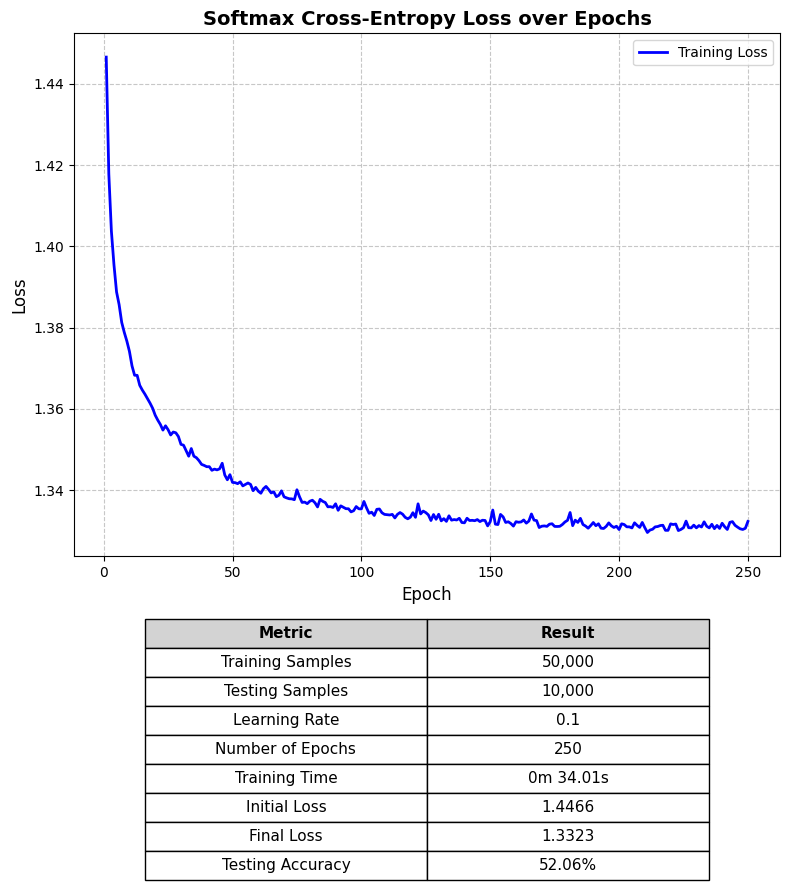

**Softmax Results**

Softmax trained on raw pixels hit ~35–40% accuracy. Swapping in HOG features pushed that to ~48–52%. As seen above, the testing accuracy got pushed to 52.06% without a proper CNN/DL architecture. It seems that 250 Epochs with learning rate 0.1 worked!

**Why HOG?**

Softmax is a linear classifier — it draws straight boundaries through the feature space. Raw pixels are a terrible input for this: small shifts to lighting or displacement changes the whole array even though the image is essentially the same. Softmax has no way to know they're related.

HOG fixes this by throwing out raw color values and measuring edge gradients instead — the *shapes* in the image rather than the exact pixel colors. That turns a messy, non-linear pixel space into something a linear classifier can work with

**The Tuning Problem**

Finding the right HOG cell size on 32×32 images was the main challenge. Large cells (8×8) over-compressed the features — too blurry to separate classes. Tiny cells (2×2) generated 8,100+ features per image, most of it noise, causing overfitting and took over two hours to run. A 4×4 grid was the sweet spot.

**The Ceiling**

HOG + Softmax tops out around 50–55% on CIFAR-10. CNNs can learn their own features directly from pixels, handle spatial variance automatically, and don't need rigid grids at all.